This is a sample for calculating embedding metrics from h5ad files.
(scRNA-NKT dataset)

In [ ]:
import logging
logging.getLogger('cuml').setLevel(logging.WARNING)
import cuml
cuml.common.logger.set_level(cuml.common.logger.level_enum.warn)

import sys
sys.path.append('/home/zzj/lare/new_evaluations/evaluation_utils')
from evaluation_utils import cal_calinski_harabasz, cal_davies_bouldin
from evaluation_rapids import cal_silhouette_score_gpu, cal_modularity_score_gpu,cal_modularity_score_gpu_fast
import scanpy as sc
import rapids_singlecell as rsc

cal_silhouette_score=cal_silhouette_score_gpu
# cal_calinski_harabasz=cal_calinski_harabasz_gpu
# cal_davies_bouldin=cal_davies_bouldin_gpu
cal_modularity_score=cal_modularity_score_gpu_fast

def do_test(adata, embedding_key, cluster_key):
    n_clusters = adata.obs[cluster_key].nunique()
    if n_clusters < 2 or n_clusters > 35:
        return None, None, None, None, None
    
    rsc.pp.neighbors(adata, use_rep=embedding_key, metric='cosine')

    silhouette_score=cal_silhouette_score(adata, embedding_key, cluster_key, metric='cosine')
    calinski_harabasz=cal_calinski_harabasz(adata, embedding_key, cluster_key, l2_normalize=True)
    davies_bouldin=cal_davies_bouldin(adata, embedding_key, cluster_key, l2_normalize=True)
    modularity_score=cal_modularity_score(adata, cluster_key)
    return n_clusters, silhouette_score, calinski_harabasz, davies_bouldin, modularity_score

def recluster_leiden(adata, resolution=1.0, embedding_key='X_umap_LassoARE', adding_col='leiden_LassoARE', random_state=0):
    rsc.pp.neighbors(adata, use_rep=embedding_key)
    rsc.tl.leiden(adata, resolution=resolution, key_added=adding_col, random_state=random_state)
    return adata

def conduct_single_test(adata, embedding_key, cluster_key, resolution=1.0, random_state=0):
    adata=recluster_leiden(adata, resolution=resolution, embedding_key=embedding_key, adding_col=cluster_key, random_state=random_state)
    return do_test(adata, embedding_key, cluster_key)

/home/zzj/anaconda3/envs/rapids_sc/lib/python3.12/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
/home/zzj/anaconda3/envs/rapids_sc/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
results = []
n_repeats = 10
resolutions = [0.05, 0.1, 0.2, 0.5, 0.8, 1.0, 1.2, 1.5] 

for res in resolutions:
    print(f'Testing resolution: {res}')
    
    methods_data = [
        ('scVI', '/home/zzj/lare/new_evaluations/new_scRNA/data/scvi_NK_releiden.h5ad', 'X_scVI'),
        ('scFoundation', '/home/zzj/lare/new_evaluations/new_scRNA/data/scFoundation_breast_releiden.h5ad', 'scFoundation_embedding'),
        ('scNET', '/home/zzj/lare/other_approaches/scNET/do_scNET/data/scNET_breast.h5ad', 'X_scNET'),
        ('LassoARE_wolasso', '/home/zzj/lare/new_evaluations/new_scRNA/data/reclustered_adata_test_woLasso_42_rsc_releiden.h5ad', 'LassoARE_latent'),
        ('LassoARE_lasso', '/home/zzj/lare/new_evaluations/new_scRNA/data/reclustered_adata_test_42_rsc_releiden.h5ad', 'LassoARE_latent')
    ]
    
    for method_name, path, embedding_key in methods_data:
        print(f'Running {method_name}...')
        adata = sc.read_h5ad(path)
        for seed in range(n_repeats):
            cluster_key = f'leiden_{res}_{seed}'
            res_tuple = conduct_single_test(adata, embedding_key, cluster_key, resolution=res, random_state=seed)
            
            if res_tuple[0] is not None:
                results.append({
                    'Method': method_name,
                    'Resolution': res,
                    'Seed': seed,
                    'Number of Clusters': res_tuple[0],
                    'Silhouette Score': res_tuple[1],
                    'Calinski-Harabasz Score': res_tuple[2],
                    'Davies-Bouldin Score': res_tuple[3],
                    'Modularity Score': res_tuple[4]
                })
            else:
                print(f"Warning: {method_name} at resolution {res} with seed {seed} produced invalid number of clusters. Skipped.")
         
# save results to DataFrame for easier plotting
import pandas as pd
results_df = pd.DataFrame(results)       
results_df.to_csv('clustering_results_with_bar.csv', index=False)

Testing resolution: 0.05
Running scVI...
[2026-04-15 17:53:23.837] [CUML] [debug] n_neighbors=15
[2026-04-15 17:53:23.837] [CUML] [debug] Calling knn graph run
[2026-04-15 17:53:23.837] [CUML] [debug] Done. Calling fuzzy simplicial set
[2026-04-15 17:53:23.944] [CUML] [debug] Done. Calling remove zeros
[2026-04-15 17:53:25.444] [CUML] [debug] Calling UMAP::get_graph() with precomputed KNN
[2026-04-15 17:53:25.444] [CUML] [debug] n_neighbors=15
[2026-04-15 17:53:25.444] [CUML] [debug] Calling knn graph run
[2026-04-15 17:53:25.444] [CUML] [debug] Done. Calling fuzzy simplicial set
[2026-04-15 17:53:25.447] [CUML] [debug] Done. Calling remove zeros
[2026-04-15 17:53:26.758] [CUML] [debug] Calling UMAP::get_graph() with precomputed KNN
[2026-04-15 17:53:26.758] [CUML] [debug] n_neighbors=15
[2026-04-15 17:53:26.758] [CUML] [debug] Calling knn graph run
[2026-04-15 17:53:26.758] [CUML] [debug] Done. Calling fuzzy simplicial set
[2026-04-15 17:53:26.768] [CUML] [debug] Done. Calling remove 

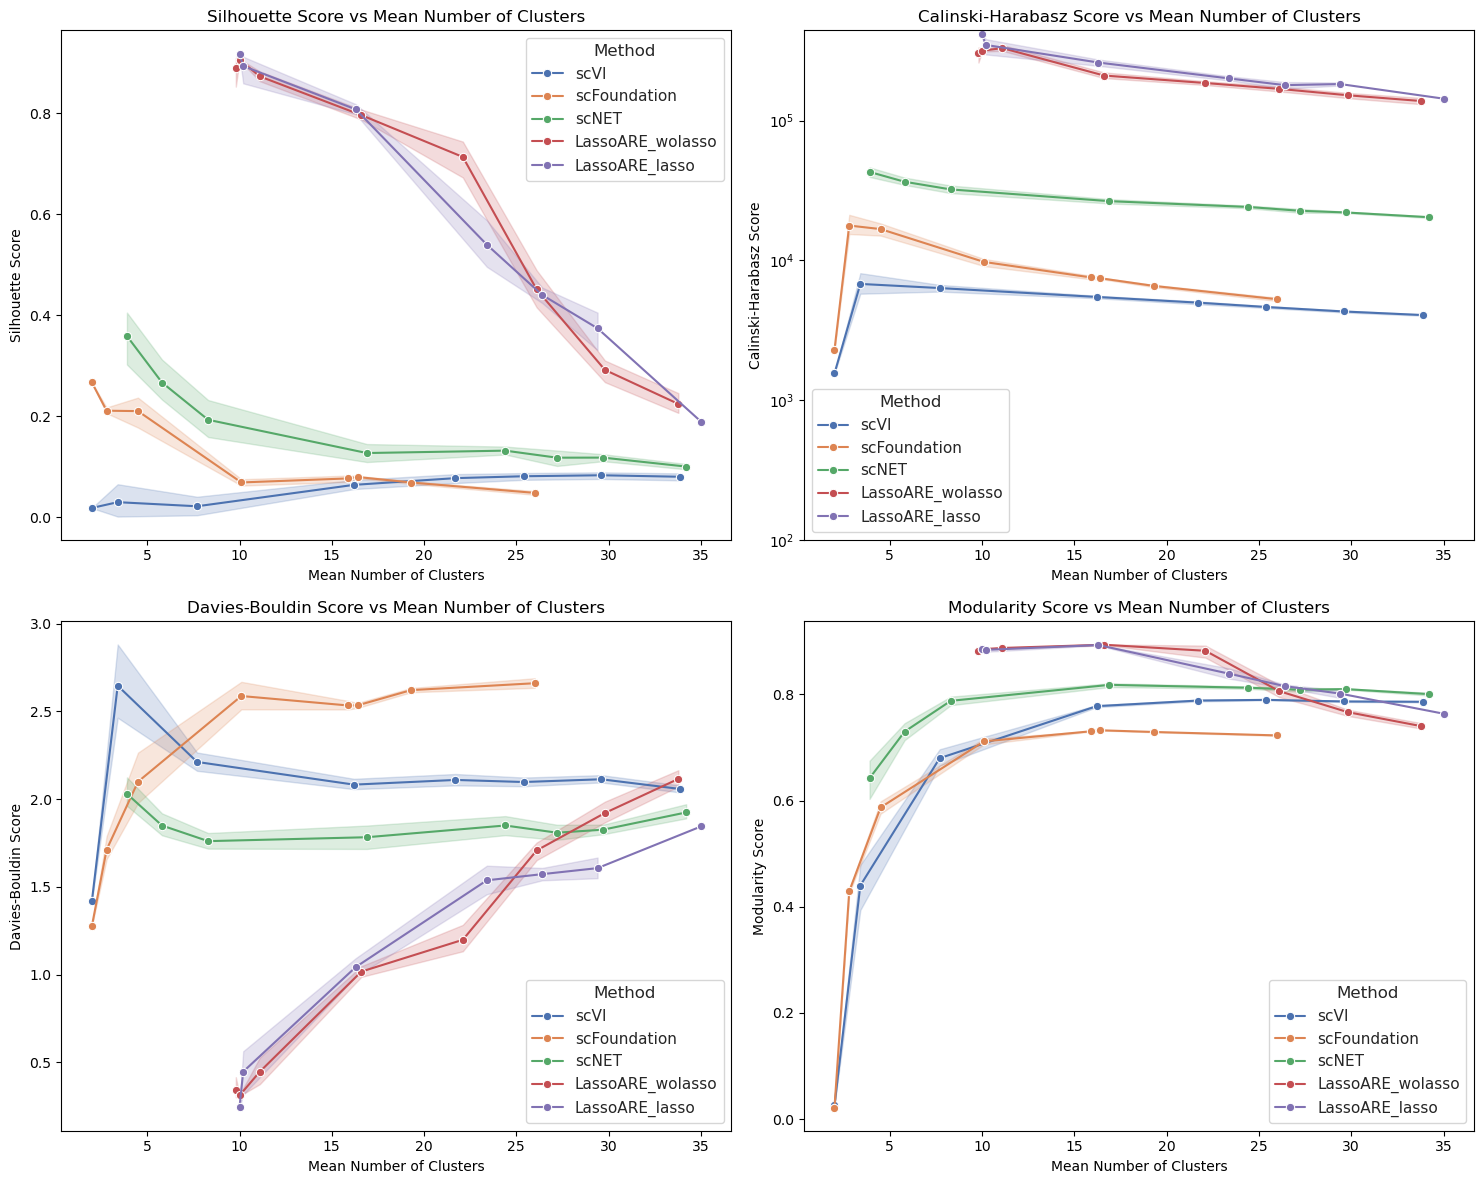

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
df = pd.read_csv('clustering_results_with_bar.csv')

metrics = ['Silhouette Score', 'Calinski-Harabasz Score', 'Davies-Bouldin Score', 'Modularity Score']

if not df.empty:
    df['Mean Number of Clusters'] = df.groupby(['Method', 'Resolution'])['Number of Clusters'].transform('mean')

    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    axes = axes.flatten()

    sns.set_theme(style="whitegrid")

    for i, metric in enumerate(metrics):
        ax = axes[i]
        sns.lineplot(
            data=df, 
            x='Mean Number of Clusters', 
            y=metric, 
            hue='Method', 
            marker='o',
            errorbar=('ci', 95),  
            ax=ax
        )
        
        ax.set_title(f'{metric} vs Mean Number of Clusters')
        ax.set_xlabel('Mean Number of Clusters')
        if metric == 'Calinski-Harabasz Score':
            ax.set_yscale('symlog')
            ax.set_ylim(bottom=100)

    plt.tight_layout()
    plt.show()
else:
    print("No valid results to plot.")